# Economic Structure vs Crime by District

This notebook is a **standalone test notebook** for connecting the economic data to district-level crime.

## What it does
- builds a district-day crime panel from the merged crime-weather file
- cleans the 2010 economic data
- extracts the two indicators you actually have:
  - **Total Employment**
  - **Average Annual Wage**
- merges them with district crime summaries
- shows:
  - crime vs average wage
  - crime vs total employment
  - optional crime rate per 1,000 population analysis
  - a ranked district comparison table


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path("..")
if not (BASE / "processed_data").exists():
    BASE = Path(".")

PROCESSED = BASE / "processed_data"
RAW = BASE / "raw_data"

crime_weather_path = PROCESSED / "merged_weather_crime_districts_data.csv"
econ_path = RAW / "economic_data.csv"
socio_path = RAW / "socio_economic_data_2010.csv"

print("Using base:", BASE.resolve())
print("Crime-weather file exists:", crime_weather_path.exists())
print("Economic file exists:", econ_path.exists())
print("Socio file exists:", socio_path.exists())

Using base: D:\Users\Miljana\Documents\Projects+\SIAP\LA-Crime-Analysis
Crime-weather file exists: True
Economic file exists: True
Socio file exists: True


## Helper functions

In [2]:
def normalize_colname(col):
    col = str(col).strip().replace("\xa0", " ")
    return re.sub(r"\s+", " ", col)

def clean_columns(df):
    out = df.copy()
    out.columns = [normalize_colname(c) for c in out.columns]
    return out

def first_existing(df, candidates, default=None):
    normalized = {str(c).lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in normalized:
            return normalized[cand.lower()]
    return default

def parse_district_value(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r"(\d+)", str(x))
    return float(m.group(1)) if m else np.nan

def clean_us_number(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
        .replace({"nan": np.nan, "None": np.nan, "": np.nan}),
        errors="coerce"
    )

def add_district_labels(ax, x, y, labels, fontsize=8):
    for xi, yi, lab in zip(x, y, labels):
        if pd.notna(xi) and pd.notna(yi):
            ax.annotate(str(int(lab)), (xi, yi), textcoords="offset points", xytext=(4, 4), fontsize=fontsize)

def safe_polyfit_line(ax, x, y):
    mask = pd.notna(x) & pd.notna(y)
    if mask.sum() >= 2:
        z = np.polyfit(x[mask], y[mask], 1)
        p = np.poly1d(z)
        xr = np.linspace(x[mask].min(), x[mask].max(), 100)
        ax.plot(xr, p(xr), linewidth=2, linestyle="--")

## 1. Load and aggregate crime data

In [3]:
crime_weather = clean_columns(pd.read_csv(crime_weather_path))

district_col = first_existing(
    crime_weather,
    ["district", "District", "COUNCIL DISTRICT", "Council District", "council_district", "district_id", "CD", "cd"]
)
datetime_col = first_existing(
    crime_weather,
    ["DATETIME OCC", "datetime occ", "datetime", "DATE OCC", "DATE RPTD", "date"]
)
crime_col = first_existing(
    crime_weather,
    ["CRIME", "crime", "Crm Cd Desc", "crime_type"]
)

print("Detected district column:", district_col)
print("Detected datetime column:", datetime_col)
print("Detected crime column:", crime_col)

if district_col is None or datetime_col is None:
    raise ValueError("Could not detect district/date columns in merged_weather_crime_districts_data.csv")

cw = crime_weather.copy()
cw[datetime_col] = pd.to_datetime(cw[datetime_col], errors="coerce")
cw[district_col] = cw[district_col].apply(parse_district_value).astype("Int64")
cw["date"] = cw[datetime_col].dt.floor("D")
cw = cw.dropna(subset=["date", district_col]).copy()

panel = (
    cw.groupby([district_col, "date"], as_index=False)
      .agg({crime_col: "count"} if crime_col is not None else {})
      .rename(columns={district_col: "district", crime_col: "crime_count"})
)

if "crime_count" not in panel.columns:
    panel["crime_count"] = 1

panel["district"] = panel["district"].astype("Int64")
panel = panel.sort_values(["district", "date"]).reset_index(drop=True)

panel.head()

Detected district column: DISTRICT
Detected datetime column: DATETIME OCC
Detected crime column: CRIME


,district,date,crime_count
0,1,2010-01-01,150
1,1,2010-01-02,29
2,1,2010-01-03,23
3,1,2010-01-04,20
4,1,2010-01-05,20


In [4]:
district_crime = (
    panel.groupby("district")
    .agg(
        avg_daily_crime=("crime_count", "mean"),
        total_crime=("crime_count", "sum"),
        days_observed=("date", "nunique")
    )
    .reset_index()
    .sort_values("avg_daily_crime", ascending=False)
)

district_crime

,district,avg_daily_crime,total_crime,days_observed
7,8,53.634721,195874,3652
13,14,51.950986,189725,3652
8,9,47.522453,173552,3652
12,13,44.746166,163413,3652
9,10,43.963855,160556,3652
14,15,38.395126,140219,3652
5,6,36.643483,133822,3652
3,4,35.721796,130456,3652
10,11,35.035597,127950,3652
2,3,34.220975,124975,3652


## 2. Load and clean economic data (2010 only)

In [5]:
economic_data = clean_columns(pd.read_csv(econ_path))

economic_data["council_district"] = pd.to_numeric(economic_data["council_district"], errors="coerce")
economic_data = economic_data[economic_data["council_district"].isin(range(1, 16))].copy()
economic_data = economic_data[economic_data["cy_qtr"].isin(["2010-01", "2010-02", "2010-03", "2010-04"])].copy()

economic_data["value_num"] = clean_us_number(economic_data["value"])

print("Indicators available:")
print(economic_data["indicator"].dropna().unique())

economic_data.head()

Indicators available:
<StringArray>
[              'Multi-family Permit Values',
                     'Multi-family Permits',
             'New Commercial Permit Values',
 'Non-residential Alteration Permit Values',
            'Non-residential Permit Values',
              'Single-family Permit Values',
                    'Single-family Permits',
         'Employment By Establishment Size',
         'Employment By Establishment Wage',
                   'Employment By Industry',
         'Establishment Change By Industry',
                         'Total Employment',
                      'Average Annual Wage']
Length: 13, dtype: str


,category,indicator,sub_indicator,locality,gender,council_district,fiscal_year,fy_qtr,calendar_year,cy_qtr,quarter_start,as_of_date,unit_of_measure,unit_text,value,source,CD #,Proportions,value_num
25,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1.0,2010,2010-03,2010.0,2010-01,01/01/2010,05/08/2015,$,Seasonally Adjusted And Smoothed,"5,787,811.5",City Of Los Angeles Department Of Building And...,1.0,NaN,5787811.5
26,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1.0,2010,2010-04,2010.0,2010-02,04/01/2010,05/08/2015,$,Seasonally Adjusted And Smoothed,0,City Of Los Angeles Department Of Building And...,1.0,NaN,0.0
27,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1.0,2010,2011-01,2011.0,2010-03,07/01/2010,05/08/2015,$,Seasonally Adjusted And Smoothed,0,City Of Los Angeles Department Of Building And...,1.0,NaN,0.0
28,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1.0,2010,2011-02,2011.0,2010-04,10/01/2010,05/08/2015,$,Seasonally Adjusted And Smoothed,"15,185,973.3",City Of Los Angeles Department Of Building And...,1.0,NaN,15185973.3
69,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,2.0,2010,2010-03,2010.0,2010-01,01/01/2010,05/08/2015,$,Seasonally Adjusted And Smoothed,"476,251",City Of Los Angeles Department Of Building And...,2.0,NaN,476251.0


In [6]:
wage_by_district = (
    economic_data[economic_data["indicator"] == "Average Annual Wage"]
    .groupby("council_district", as_index=False)["value_num"]
    .mean()
    .rename(columns={"value_num": "avg_annual_wage"})
)

employment_by_district = (
    economic_data[economic_data["indicator"] == "Total Employment"]
    .groupby("council_district", as_index=False)["value_num"]
    .mean()
    .rename(columns={"value_num": "total_employment"})
)

wage_by_district, employment_by_district.head()

(    council_district  avg_annual_wage
 0                1.0        43103.825
 1                2.0        42191.225
 2                3.0        52878.850
 3                4.0        62295.000
 4                5.0        78815.650
 5                6.0        43998.925
 6                7.0        45148.325
 7                8.0        29165.575
 8                9.0        42437.450
 9               10.0        42641.950
 10              11.0        61785.750
 11              12.0        43272.975
 12              13.0        54527.125
 13              14.0        69560.925
 14              15.0        48426.875,
    council_district  total_employment
 0               1.0         93946.450
 1               2.0         59406.375
 2               3.0         97065.050
 3               4.0         98931.325
 4               5.0        189243.725)

## 3. Optional population data for crime rate per 1,000

In [7]:
pop_by_district = None

if socio_path.exists():
    socio = clean_columns(pd.read_csv(socio_path))
    socio_district_col = first_existing(
        socio,
        ["Council District", "council_district", "district", "CD #", "CD#", "CD"]
    )
    if socio_district_col is not None:
        socio["district"] = socio[socio_district_col].apply(parse_district_value).astype("Int64")
        if "Pop2010" in socio.columns:
            socio["Pop2010"] = clean_us_number(socio["Pop2010"])
            pop_by_district = socio[["district", "Pop2010"]].dropna().drop_duplicates("district")
            print("Population data loaded.")
        else:
            print("Pop2010 not found in socio data.")
    else:
        print("District column not found in socio data.")
else:
    print("No socio data file found; rate-per-1000 section will be skipped.")

pop_by_district

Population data loaded.


,district,Pop2010
0,1,245216.22
1,10,261297.85
2,11,250726.93
3,12,258715.95
4,13,247142.04
5,14,248489.10
6,15,251283.55
7,2,256691.84
8,3,257183.29
9,4,244117.22


## 4. Merge crime + economic data

In [8]:
district_econ_crime = (
    district_crime
    .merge(wage_by_district, left_on="district", right_on="council_district", how="left")
    .merge(employment_by_district, left_on="district", right_on="council_district", how="left", suffixes=("_wage", "_employment"))
)

drop_cols = [c for c in district_econ_crime.columns if "council_district" in c]
district_econ_crime = district_econ_crime.drop(columns=drop_cols)

if pop_by_district is not None:
    district_econ_crime = district_econ_crime.merge(pop_by_district, on="district", how="left")
    district_econ_crime["crime_per_1000"] = np.where(
        district_econ_crime["Pop2010"] > 0,
        district_econ_crime["total_crime"] / district_econ_crime["Pop2010"] * 1000,
        np.nan
    )

district_econ_crime = district_econ_crime.sort_values("avg_daily_crime", ascending=False).reset_index(drop=True)
district_econ_crime

,district,avg_daily_crime,total_crime,days_observed,avg_annual_wage,total_employment,Pop2010,crime_per_1000
0,8,53.634721,195874,3652,29165.575,20589.600,245838.53,796.758751
1,14,51.950986,189725,3652,69560.925,316649.000,248489.10,763.514375
2,9,47.522453,173552,3652,42437.450,70937.050,248693.15,697.855972
3,13,44.746166,163413,3652,54527.125,89061.350,247142.04,661.210857
4,10,43.963855,160556,3652,42641.950,63890.600,261297.85,614.455879
5,15,38.395126,140219,3652,48426.875,60015.925,251283.55,558.011060
6,6,36.643483,133822,3652,43998.925,71522.225,262111.74,510.553247
7,4,35.721796,130456,3652,62295.000,98931.325,244117.22,534.399007
8,11,35.035597,127950,3652,61785.750,140895.800,250726.93,510.316144
9,3,34.220975,124975,3652,52878.850,97065.050,257183.29,485.937481


## 5. Quick correlation check

In [9]:
corr_cols = ["avg_daily_crime", "avg_annual_wage", "total_employment"]
if "crime_per_1000" in district_econ_crime.columns:
    corr_cols = ["avg_daily_crime", "crime_per_1000", "avg_annual_wage", "total_employment"]

district_econ_crime[corr_cols].corr(numeric_only=True)

,avg_daily_crime,crime_per_1000,avg_annual_wage,total_employment
avg_daily_crime,1.000000,0.994956,-0.169218,0.158751
crime_per_1000,0.994956,1.000000,-0.143990,0.169800
avg_annual_wage,-0.169218,-0.143990,1.000000,0.796095
total_employment,0.158751,0.169800,0.796095,1.000000


## 6. Crime vs average annual wage

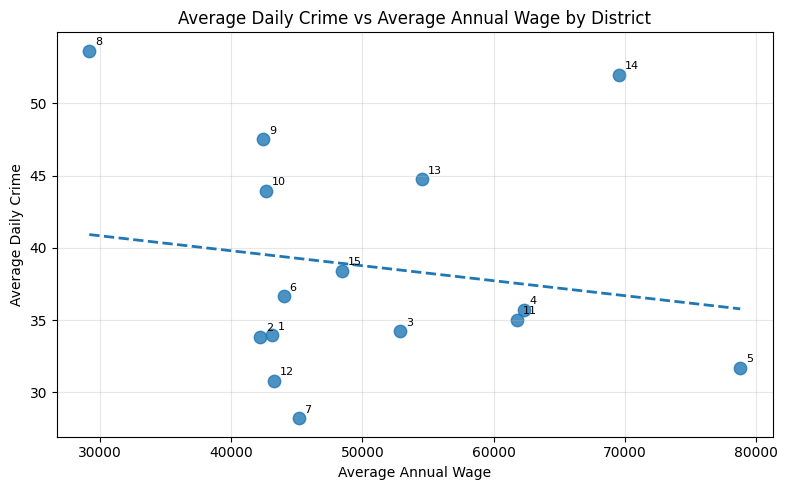

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(district_econ_crime["avg_annual_wage"], district_econ_crime["avg_daily_crime"], s=80, alpha=0.8)
add_district_labels(
    ax,
    district_econ_crime["avg_annual_wage"],
    district_econ_crime["avg_daily_crime"],
    district_econ_crime["district"]
)
safe_polyfit_line(ax, district_econ_crime["avg_annual_wage"], district_econ_crime["avg_daily_crime"])
ax.set_xlabel("Average Annual Wage")
ax.set_ylabel("Average Daily Crime")
ax.set_title("Average Daily Crime vs Average Annual Wage by District")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Crime vs total employment

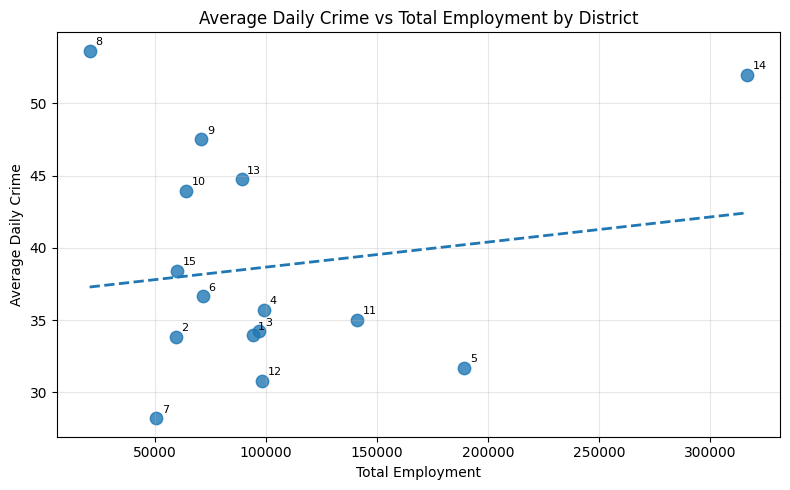

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(district_econ_crime["total_employment"], district_econ_crime["avg_daily_crime"], s=80, alpha=0.8)
add_district_labels(
    ax,
    district_econ_crime["total_employment"],
    district_econ_crime["avg_daily_crime"],
    district_econ_crime["district"]
)
safe_polyfit_line(ax, district_econ_crime["total_employment"], district_econ_crime["avg_daily_crime"])
ax.set_xlabel("Total Employment")
ax.set_ylabel("Average Daily Crime")
ax.set_title("Average Daily Crime vs Total Employment by District")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Optional rate-based versions

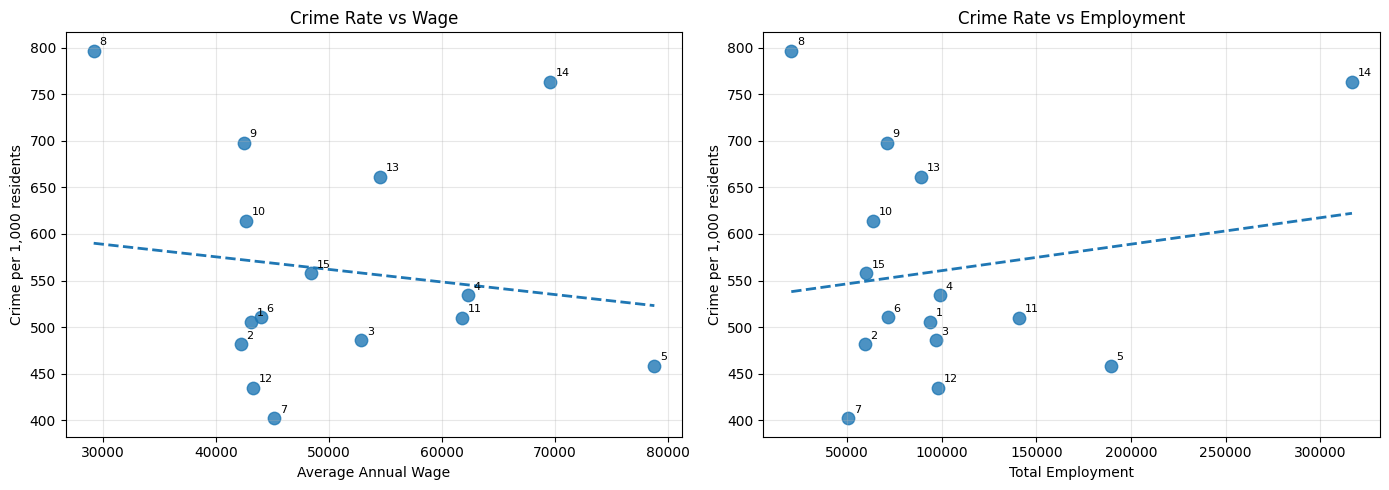

In [12]:
if "crime_per_1000" in district_econ_crime.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(district_econ_crime["avg_annual_wage"], district_econ_crime["crime_per_1000"], s=80, alpha=0.8)
    add_district_labels(
        axes[0],
        district_econ_crime["avg_annual_wage"],
        district_econ_crime["crime_per_1000"],
        district_econ_crime["district"]
    )
    safe_polyfit_line(axes[0], district_econ_crime["avg_annual_wage"], district_econ_crime["crime_per_1000"])
    axes[0].set_xlabel("Average Annual Wage")
    axes[0].set_ylabel("Crime per 1,000 residents")
    axes[0].set_title("Crime Rate vs Wage")
    axes[0].grid(alpha=0.3)

    axes[1].scatter(district_econ_crime["total_employment"], district_econ_crime["crime_per_1000"], s=80, alpha=0.8)
    add_district_labels(
        axes[1],
        district_econ_crime["total_employment"],
        district_econ_crime["crime_per_1000"],
        district_econ_crime["district"]
    )
    safe_polyfit_line(axes[1], district_econ_crime["total_employment"], district_econ_crime["crime_per_1000"])
    axes[1].set_xlabel("Total Employment")
    axes[1].set_ylabel("Crime per 1,000 residents")
    axes[1].set_title("Crime Rate vs Employment")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("crime_per_1000 not available because Pop2010 was not found.")

## 9. Ranked comparison tables

In [13]:
display_cols = ["district", "avg_daily_crime", "total_crime", "avg_annual_wage", "total_employment"]
if "crime_per_1000" in district_econ_crime.columns:
    display_cols.insert(2, "crime_per_1000")

district_econ_crime[display_cols].sort_values("avg_daily_crime", ascending=False).reset_index(drop=True)

,district,avg_daily_crime,crime_per_1000,total_crime,avg_annual_wage,total_employment
0,8,53.634721,796.758751,195874,29165.575,20589.600
1,14,51.950986,763.514375,189725,69560.925,316649.000
2,9,47.522453,697.855972,173552,42437.450,70937.050
3,13,44.746166,661.210857,163413,54527.125,89061.350
4,10,43.963855,614.455879,160556,42641.950,63890.600
5,15,38.395126,558.011060,140219,48426.875,60015.925
6,6,36.643483,510.553247,133822,43998.925,71522.225
7,4,35.721796,534.399007,130456,62295.000,98931.325
8,11,35.035597,510.316144,127950,61785.750,140895.800
9,3,34.220975,485.937481,124975,52878.850,97065.050
